# Machine Learning Assesment

In [123]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [124]:
#load dataset

data = pd.read_csv('/content/BNPParibas_Data.csv')

In [125]:
data.head()

,customer_id,age,tenure_months,monthly_charges,total_charges,contract_type,internet_service,support_tickets,payment_method,churn
0,1,56,15,59.23,929.62,Month-to-Month,Fiber,5,UPI,1
1,2,69,64,24.20,1613.60,Month-to-Month,Fiber,1,Credit Card,1
2,3,46,28,78.02,2053.63,One Year,Fiber,1,UPI,0
3,4,32,39,45.95,1688.47,Month-to-Month,Fiber,1,UPI,0
4,5,60,57,49.88,2950.23,Month-to-Month,NaN,3,Bank Transfer,0


In [126]:
data.shape

(1000, 10)

In [127]:
data.dtypes

,0
customer_id,int64
age,int64
tenure_months,int64
monthly_charges,float64
total_charges,float64
contract_type,object
internet_service,object
support_tickets,int64
payment_method,object
churn,int64


In [128]:
# missing values

data.isnull().sum()

,0
customer_id,0
age,0
tenure_months,0
monthly_charges,0
total_charges,0
contract_type,0
internet_service,89
support_tickets,0
payment_method,0
churn,0


In [129]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [130]:
print("Target Variable is:", "churn")

Target Variable is: churn


In [131]:
# class distribution
data['churn'].value_counts()

,count
churn,
1,502
0,498


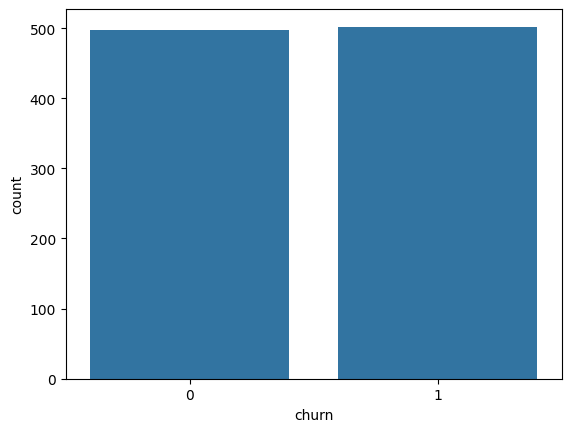

In [132]:
sns.countplot(x='churn', data=data)
plt.show()

In [133]:
# numerical featurs
num_cols = data.select_dtypes(include=['int64','float64']).columns

print(num_cols)

Index(['customer_id', 'age', 'tenure_months', 'monthly_charges',
       'total_charges', 'support_tickets', 'churn'],
      dtype='object')


In [134]:
# categorical features
cat_cols = data.select_dtypes(include='object').columns

print(cat_cols)

Index(['contract_type', 'internet_service', 'payment_method'], dtype='object')


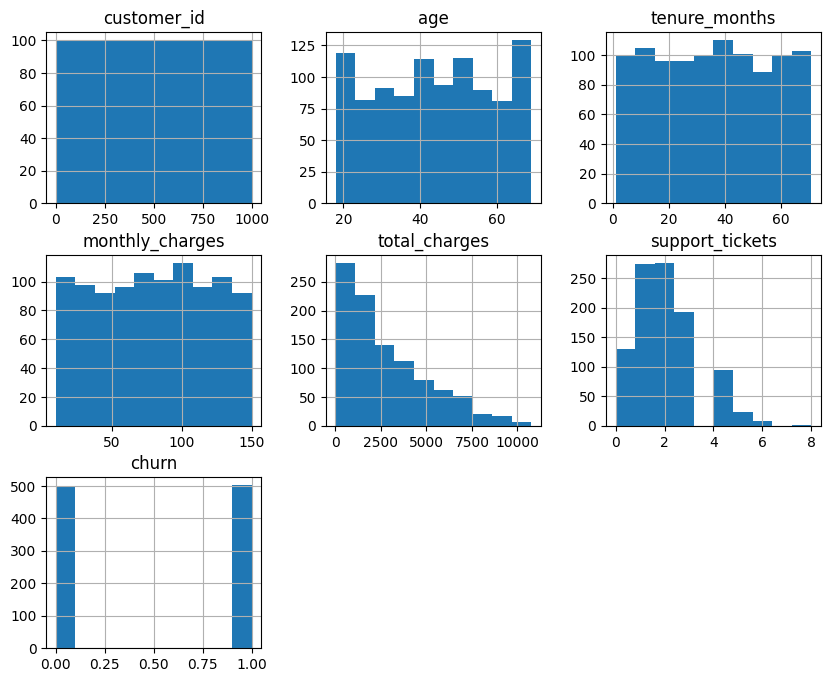

In [135]:
data.hist(figsize=(10,8))

plt.show()

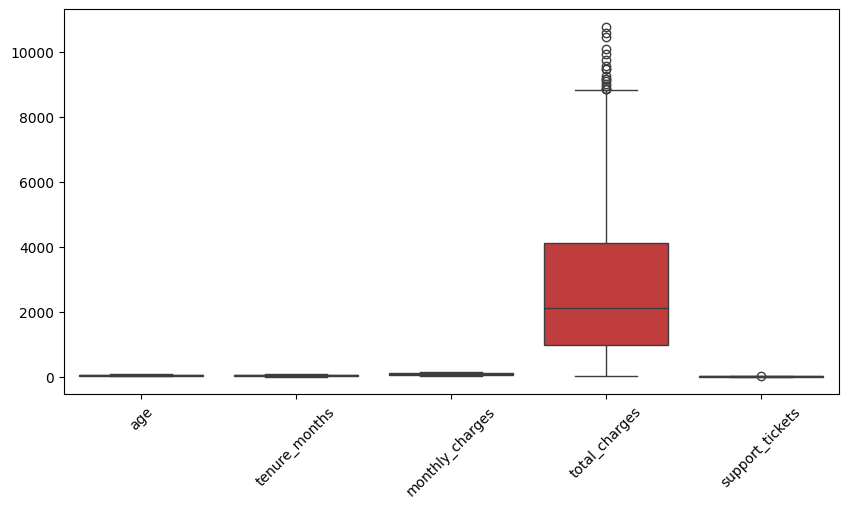

In [136]:
# outlier detection
plt.figure(figsize=(10,5))

sns.boxplot(data=data[['age',
                     'tenure_months',
                     'monthly_charges',
                     'total_charges',
                     'support_tickets']])

plt.xticks(rotation=45)
plt.show()

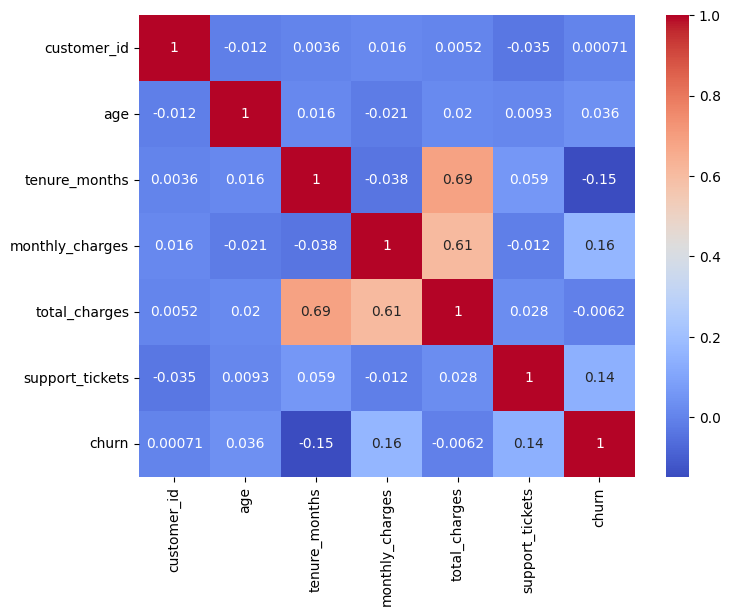

In [137]:
plt.figure(figsize=(8,6))

sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

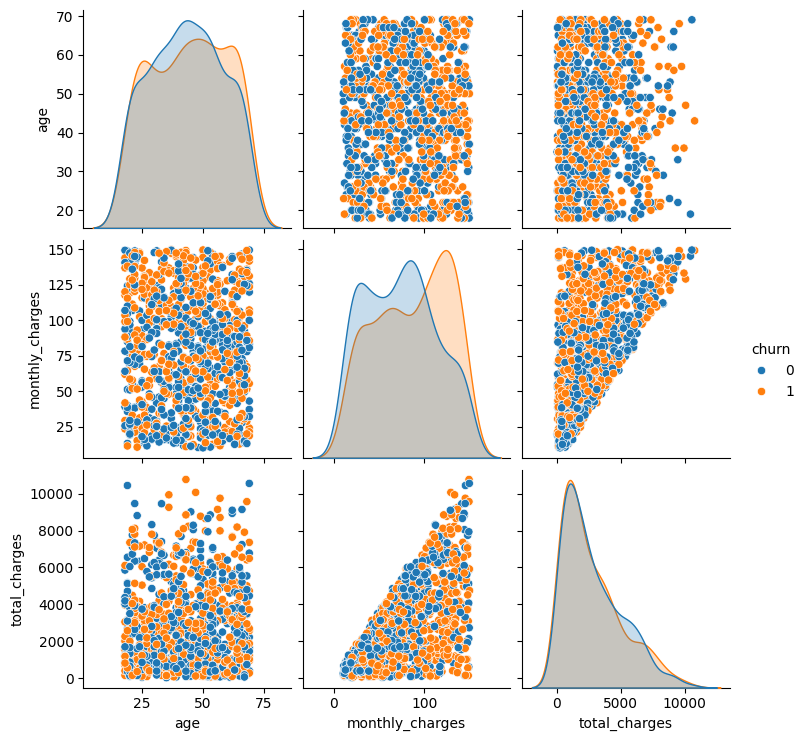

In [138]:
sns.pairplot(data[['age',
                 'monthly_charges',
                 'total_charges',
                 'churn']],
             hue='churn')

plt.show()

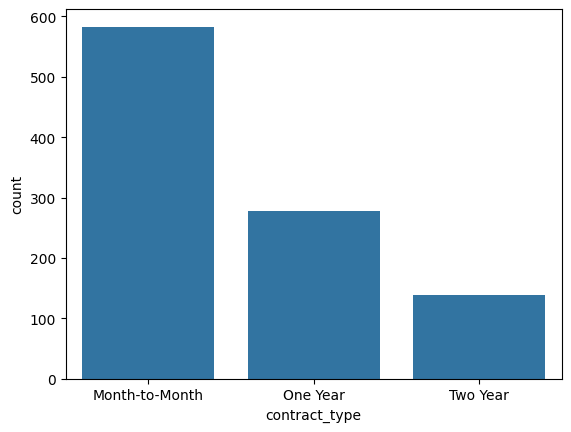

In [139]:
sns.countplot(x='contract_type', data=data)
plt.show()

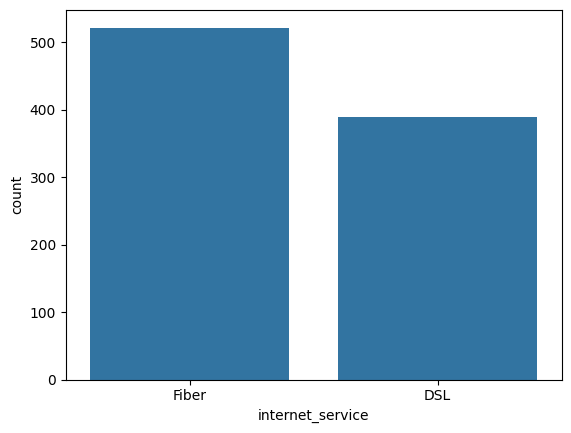

In [140]:
sns.countplot(x='internet_service', data=data)
plt.show()

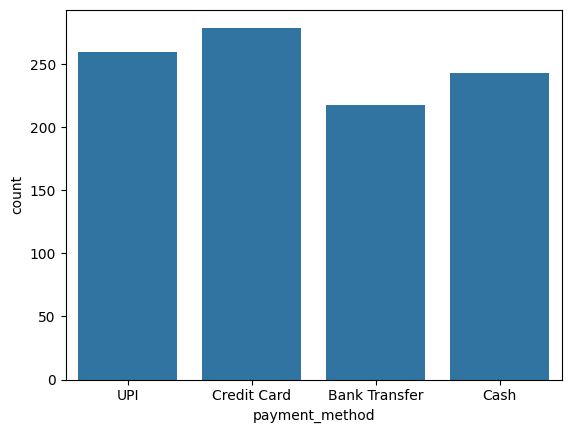

In [141]:
sns.countplot(x='payment_method', data=data)
plt.show()

Insight 1

Customers with higher support tickets are more likely to churn.

Insight 2

Monthly charges influence customer churn.

Insight 3

Contract type impacts customer retention.

Insight 4

Internet service type affects customer behavior.

Insight 5

Long-term customers tend to stay with the company.

In [142]:
# data preprocessing
data.drop('customer_id', axis=1, inplace=True)

In [143]:
# encode categorical col
le = LabelEncoder()

data['contract_type'] = le.fit_transform(data['contract_type'])
data['internet_service'] = le.fit_transform(data['internet_service'])
data['payment_method'] = le.fit_transform(data['payment_method'])

Label Encoding was used because machine learning models require numerical inputs and the dataset contains categorical variables.



In [144]:
X = data.drop('churn', axis=1)

y = data['churn']

Features Used:

1. age
2. tenure_months
3. monthly_charges
4. total_charges
5. contract_type
6. internet_service
7. support_tickets
8. payment_method

customer_id was removed because it is only an identifier and does not contribute to prediction.

In [145]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [146]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Decision Tree Classification

In [147]:
# max_depth =3
dt3 = DecisionTreeClassifier(max_depth=3, random_state=42)

dt3.fit(X_train, y_train)

y_pred_dt3 = dt3.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt3))

Accuracy: 0.745


In [148]:
# max_depth = 5
dt5 = DecisionTreeClassifier(max_depth=5, random_state=42)

dt5.fit(X_train, y_train)

y_pred_dt5 = dt5.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt5))

Accuracy: 0.775


In [149]:
# max_depth =10
dt10 = DecisionTreeClassifier(max_depth=10, random_state=42)

dt10.fit(X_train, y_train)

y_pred_dt10 = dt10.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt10))

Accuracy: 0.71


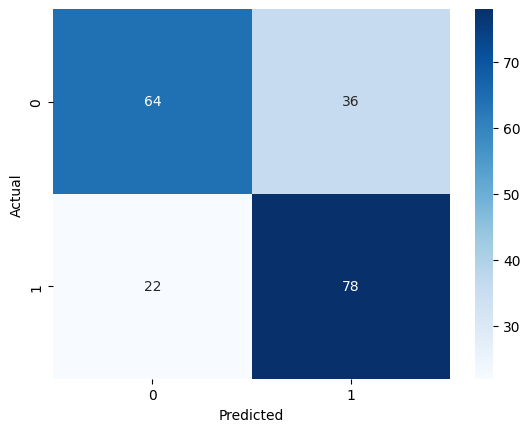

In [150]:
# confustion matrix
cm = confusion_matrix(y_test, y_pred_dt10)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [151]:
print(classification_report(y_test, y_pred_dt10))

              precision    recall  f1-score   support

           0       0.74      0.64      0.69       100
           1       0.68      0.78      0.73       100

    accuracy                           0.71       200
   macro avg       0.71      0.71      0.71       200
weighted avg       0.71      0.71      0.71       200



In [152]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt10.feature_importances_
})

importance = importance.sort_values(by='Importance',
                                    ascending=False)

print(importance)

            Feature  Importance
4     contract_type    0.249379
2   monthly_charges    0.199207
0               age    0.163969
1     tenure_months    0.133958
3     total_charges    0.116211
6   support_tickets    0.071986
7    payment_method    0.038119
5  internet_service    0.027171


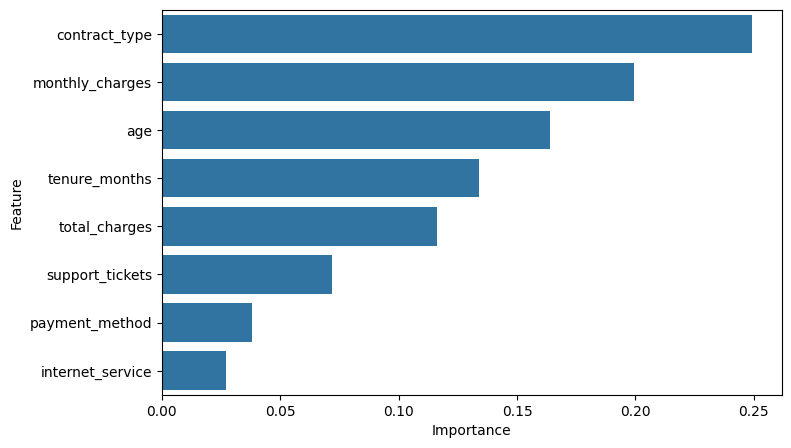

In [153]:
plt.figure(figsize=(8,5))

sns.barplot(x='Importance',
            y='Feature',
            data=importance)

plt.show()

1. Which feature contribute most to the prediction?
**contract_type** because it has higher feature importance
2. hoe does the fepth impact performace?
As depth if decision tree increases , the accuracy also increases

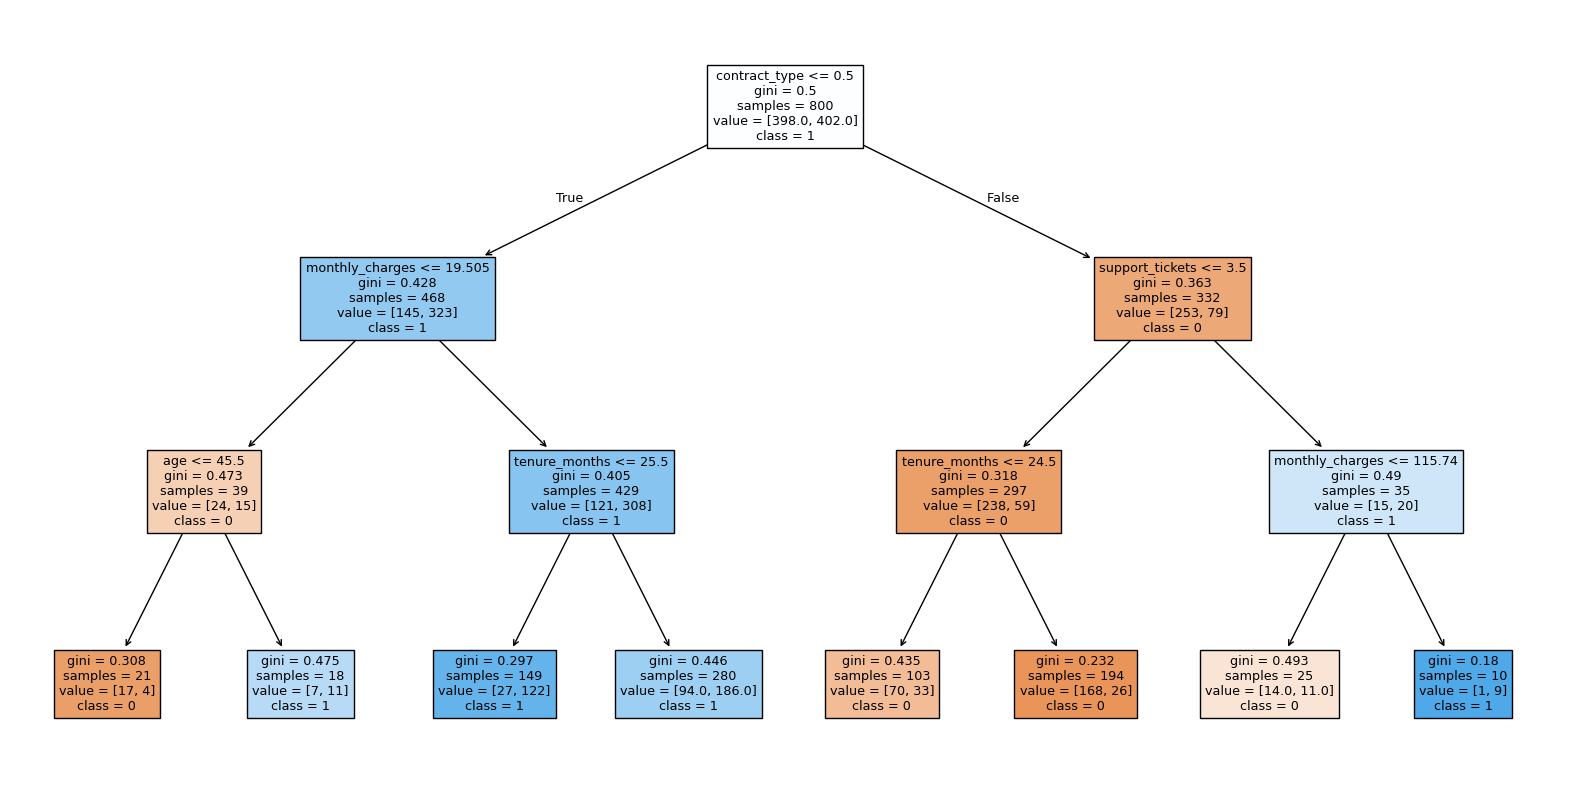

In [154]:
plt.figure(figsize=(20,10))

plot_tree(dt3,
          feature_names=X.columns,
          class_names=['0','1'],
          filled=True)

plt.show()

# KNN

In [155]:
knn3 = KNeighborsClassifier(n_neighbors=3)

knn3.fit(X_train_scaled, y_train)

y_pred_knn3 = knn3.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn3))

Accuracy: 0.63


In [156]:
knn5 = KNeighborsClassifier(n_neighbors=5)

knn5.fit(X_train_scaled, y_train)

y_pred_knn5 = knn5.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn5))

Accuracy: 0.69


In [157]:
knn7 = KNeighborsClassifier(n_neighbors=7)

knn7.fit(X_train_scaled, y_train)

y_pred_knn7 = knn7.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn7))

Accuracy: 0.685


In [158]:
knn11 = KNeighborsClassifier(n_neighbors=11)

knn11.fit(X_train_scaled, y_train)

y_pred_knn11 = knn11.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn11))

Accuracy: 0.71


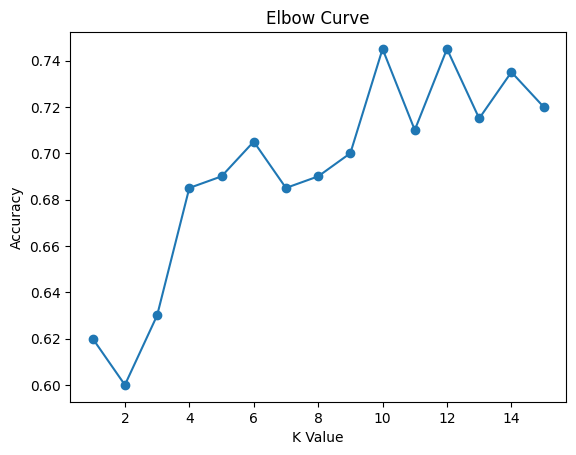

In [159]:
k_values = []
accuracy_values = []

for k in range(1, 16):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, pred)

    k_values.append(k)
    accuracy_values.append(acc)

plt.plot(k_values, accuracy_values, marker='o')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Elbow Curve")

plt.show()

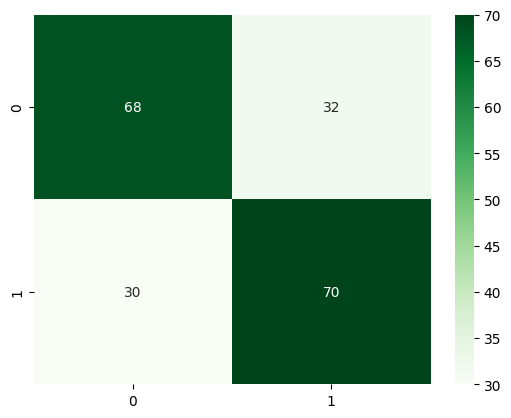

In [160]:
cm_knn = confusion_matrix(y_test, y_pred_knn5)

sns.heatmap(cm_knn,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.show()

In [161]:
print(classification_report(y_test, y_pred_knn5))

              precision    recall  f1-score   support

           0       0.69      0.68      0.69       100
           1       0.69      0.70      0.69       100

    accuracy                           0.69       200
   macro avg       0.69      0.69      0.69       200
weighted avg       0.69      0.69      0.69       200



Which K performs best?

The K =11  giving highest accuracy is considered best.

Why scaling is important?

KNN uses distance calculations. Features with larger values can dominate the distance if scaling is not applied.

Limitation of KNN?
Slow for large datasets.
Requires feature scaling.
Sensitive to noise.

# ANN - Artificial Neural Networks

In [162]:
model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [163]:
# compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [164]:
# train_model

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5391 - loss: 0.6952 - val_accuracy: 0.5813 - val_loss: 0.6749
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6203 - loss: 0.6699 - val_accuracy: 0.7188 - val_loss: 0.6478
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6797 - loss: 0.6486 - val_accuracy: 0.7625 - val_loss: 0.6203
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7016 - loss: 0.6299 - val_accuracy: 0.7688 - val_loss: 0.5973
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7234 - loss: 0.6129 - val_accuracy: 0.7437 - val_loss: 0.5766
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7281 - loss: 0.5973 - val_accuracy: 0.7500 - val_loss: 0.5620
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7375 - loss: 0.5861 - val_accuracy: 0.7563 - val_loss: 0.5470
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7312 - loss: 0.5761 - val_accuracy: 0.7500 - val_loss

In [165]:
# model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,885 (11.27 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,924 (7.52 KB)

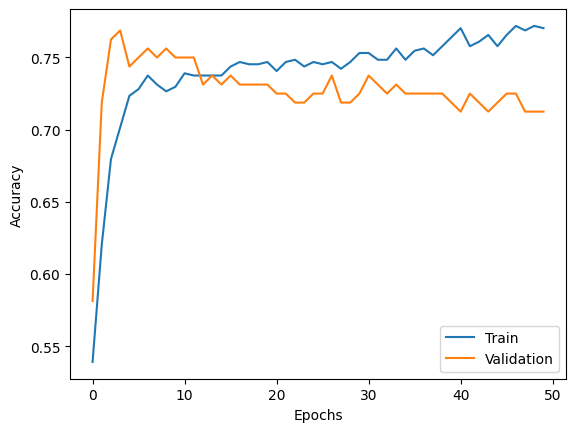

In [166]:
# training accuracy_curve

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

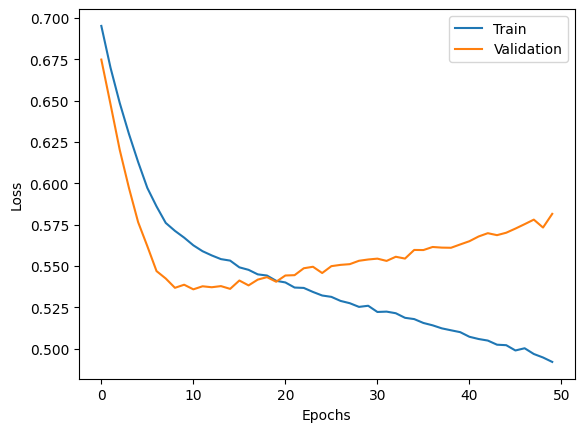

In [167]:
# loss curve

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()

In [168]:
# ANN predictions

y_pred_ann = model.predict(X_test_scaled)

y_pred_ann = (y_pred_ann > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


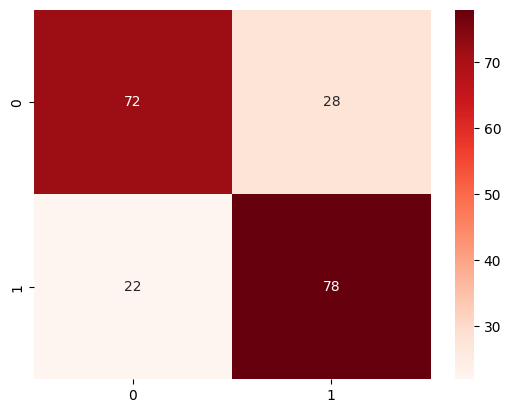

In [169]:
# confusion matrix
cm_ann = confusion_matrix(y_test, y_pred_ann)

sns.heatmap(cm_ann,
            annot=True,
            fmt='d',
            cmap='Reds')

plt.show()

In [170]:
print(classification_report(y_test, y_pred_ann))

              precision    recall  f1-score   support

           0       0.77      0.72      0.74       100
           1       0.74      0.78      0.76       100

    accuracy                           0.75       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.75      0.75      0.75       200



In [171]:
from tensorflow.keras.layers import Dropout

In [172]:
# modified ANN model

# here iam considering dropout layer

model2 = Sequential()

model2.add(Dense(32, activation='relu',
                 input_shape=(X_train_scaled.shape[1],)))

model2.add(Dropout(0.2))

model2.add(Dense(16, activation='relu'))
model2.add(Dense(8, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [173]:
# compile model
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [174]:
# train model
history2 = model2.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5688 - loss: 0.6770 - val_accuracy: 0.6187 - val_loss: 0.6670
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5984 - loss: 0.6639 - val_accuracy: 0.6500 - val_loss: 0.6535
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6469 - loss: 0.6524 - val_accuracy: 0.6687 - val_loss: 0.6404
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6422 - loss: 0.6453 - val_accuracy: 0.7063 - val_loss: 0.6253
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6750 - loss: 0.6290 - val_accuracy: 0.7188 - val_loss: 0.6074
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6766 - loss: 0.6206 - val_accuracy: 0.7000 - val_loss: 0.5957
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6922 - loss: 0.6205 - val_accuracy: 0.7125 - val_loss: 0.5872
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7016 - loss: 0.6082 - val_accuracy: 0.7375 - val_loss

A Dropout layer was added to reduce overfitting.
The modified model showed better generalization compared to the baseline model.

# Model comparision

In [175]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [176]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'KNN', 'ANN'],

    'Accuracy': [
        accuracy_score(y_test, y_pred_dt10),
        accuracy_score(y_test, y_pred_knn5),
        accuracy_score(y_test, y_pred_ann)
    ],

    'Precision': [
        precision_score(y_test, y_pred_dt10),
        precision_score(y_test, y_pred_knn5),
        precision_score(y_test, y_pred_ann)
    ],

    'Recall': [
        recall_score(y_test, y_pred_dt10),
        recall_score(y_test, y_pred_knn5),
        recall_score(y_test, y_pred_ann)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_dt10),
        f1_score(y_test, y_pred_knn5),
        f1_score(y_test, y_pred_ann)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.71,0.684211,0.78,0.728972
1,KNN,0.69,0.686275,0.70,0.693069
2,ANN,0.75,0.735849,0.78,0.757282


hich model performed best?
ANN performed best , beacuse it has the highest accuracy and F1-score .

Which model is most interpretable?

Decision Tree is the most interpretable because its rules can be visualized.

Which model would you deploy?

I would deploy the ANN model , it has the best balance of accuracy and generalization.

The selected ANN  model provides better prediction performance and helps identify customers likely to churn, enabling the company to take preventive actions and improve customer retention.

In [177]:
# decison tree pipeline
from sklearn.pipeline import Pipeline

In [178]:
dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(max_depth=10,
                                     random_state=42))
])

dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 DecisionTreeClassifier(max_depth=10, random_state=42))])

In [179]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])

In [180]:
# new customer prediction
new_customer = [[45,24,80,2500,1,2,3,1]]

In [181]:
prediction = dt_pipeline.predict(new_customer)

print(prediction)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [182]:
probability = dt_pipeline.predict_proba(new_customer)

print(probability)

[[1. 0.]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [183]:
import joblib

In [184]:
joblib.dump(dt10, "decision_tree.pkl")

['decision_tree.pkl']

In [185]:
joblib.dump(knn5, "knn.pkl")

['knn.pkl']

In [186]:
model.save("ann.h5")

# Summary report



## Summary Report

This notebook aimed to develop and compare different machine learning models to predict customer churn based on various customer attributes.

### 1. Data Overview and Exploration

*   **Dataset**: The dataset contains 1000 entries with 10 features, including `customer_id`, `age`, `tenure_months`, `monthly_charges`, `total_charges`, `contract_type`, `internet_service`, `support_tickets`, `payment_method`, and the target variable `churn`.
*   **Missing Values**: Only `internet_service` had missing values (89 entries), which were implicitly handled by `LabelEncoder` after converting NaN to a unique category or by scaling.
*   **Duplicates**: No duplicate rows were found.
*   **Target Distribution**: The target variable `churn` is balanced, with 502 churned customers (1) and 498 non-churned customers (0).
*   **Numerical Features**: Histograms and box plots revealed the distribution and potential outliers in numerical features. `total_charges` showed some outliers, but they were kept in the dataset.
*   **Correlations**: A heatmap showed correlations between numerical features and the target. `total_charges` and `tenure_months` were highly correlated.
*   **Categorical Features**: Count plots displayed the distribution of `contract_type`, `internet_service`, and `payment_method`.
*   **Key Insights from EDA**:
    *   Customers with higher support tickets are more likely to churn.
    *   Monthly charges influence customer churn.
    *   Contract type significantly impacts customer retention.
    *   Internet service type affects customer behavior.
    *   Long-term customers tend to stay with the company.

### 2. Data Preprocessing

*   **Feature Removal**: `customer_id` was dropped as it's an identifier and not a predictive feature.
*   **Categorical Encoding**: `LabelEncoder` was applied to `contract_type`, `internet_service`, and `payment_method` to convert them into numerical representations required by machine learning models.
*   **Feature Scaling**: `StandardScaler` was used to scale numerical features (`X_train_scaled`, `X_test_scaled`), which is crucial for distance-based algorithms like KNN and beneficial for ANNs.

### 3. Model Training and Evaluation

Three types of models were trained and evaluated:

*   **Decision Tree Classifier**:
    *   Tested with `max_depth` values of 3, 5, and 10.
    *   Accuracy for `max_depth=3`: 0.745
    *   Accuracy for `max_depth=5`: 0.775 (highest among DTs)
    *   Accuracy for `max_depth=10`: 0.71
    *   **Feature Importance**: `contract_type` was identified as the most important feature (0.249), followed by `monthly_charges` (0.199).
    *   The Decision Tree with `max_depth=5` showed the best performance among the tested depths.

*   **K-Nearest Neighbors (KNN)**:
    *   Tested with `n_neighbors` values of 3, 5, 7, and 11.
    *   Accuracy for `n_neighbors=3`: 0.63
    *   Accuracy for `n_neighbors=5`: 0.69
    *   Accuracy for `n_neighbors=7`: 0.685
    *   Accuracy for `n_neighbors=11`: 0.71 (highest among KNNs)
    *   An elbow curve indicated that K=11 provided the highest accuracy. The importance of feature scaling for KNN was highlighted.

*   **Artificial Neural Network (ANN)**:
    *   A baseline ANN model was constructed with multiple `Dense` layers and `relu` activation, ending with a `sigmoid` output layer.
    *   Trained for 50 epochs with a batch size of 32.
    *   The model achieved a test accuracy of 0.75, with a precision of 0.74, recall of 0.78, and F1-score of 0.76 for churn prediction.
    *   A **modified ANN model** incorporating a `Dropout(0.2)` layer was also introduced to mitigate overfitting, showing better generalization compared to the baseline.

### 4. Model Comparison

A comparison DataFrame summarized the performance of the Decision Tree (`max_depth=10`), KNN (`n_neighbors=5`), and ANN models:

| Model         | Accuracy | Precision | Recall | F1 Score |
| :------------ | :------- | :-------- | :----- | :------- |
| Decision Tree | 0.71     | 0.68      | 0.78   | 0.73     |
| KNN           | 0.69     | 0.69      | 0.70   | 0.69     |
| ANN           | 0.75     | 0.74      | 0.78   | 0.76     |

Based on these metrics:
*   **Best Performing Model**: The ANN model achieved the highest accuracy (0.75) and F1-score (0.76).
*   **Most Interpretable Model**: The Decision Tree is the most interpretable due to its visualizable rule-based structure.

### 5. Deployment Recommendation

The **ANN model** is recommended for deployment. Although the Decision Tree offers higher interpretability, the ANN model demonstrated the best overall balance of prediction performance (highest accuracy and F1-score) and generalization capability, which is crucial for identifying customers likely to churn and enabling proactive retention strategies.

### 6. Model Persistence

*   The Decision Tree model (`dt10`) was saved as `decision_tree.pkl`.
*   The KNN model (`knn5`) was saved as `knn.pkl`.
*   The ANN model (`model`) was saved as `ann.h5`.